<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1742 | Val: 489 | Test: 276


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.1430 acc 0.484 | val loss 0.8929 acc 0.583 *
[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 1.0163 acc 0.579 | val loss 0.8391 acc 0.673 *
[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.9313 acc 0.628 | val loss 0.8740 acc 0.624
[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.8718 acc 0.665 | val loss 0.8474 acc 0.706
[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.8595 acc 0.650 | val loss 0.7531 acc 0.679 *
[DenseNet-121] Epoch   6/100 | LR: 2.74e-04 | train loss 0.7950 acc 0.699 | val loss 0.6282 acc 0.757 *
[DenseNet-121] Epoch   7/100 | LR: 2.74e-05 | train loss 0.7738 acc 0.696 | val loss 0.6064 acc 0.771 *
[DenseNet-121] Epoch   8/100 | LR: 2.74e-05 | train loss 0.5795 acc 0.776 | val loss 0.5458 acc 0.789 *
[DenseNet-121] Epoch   9/100 | LR: 2.74e-05 | train

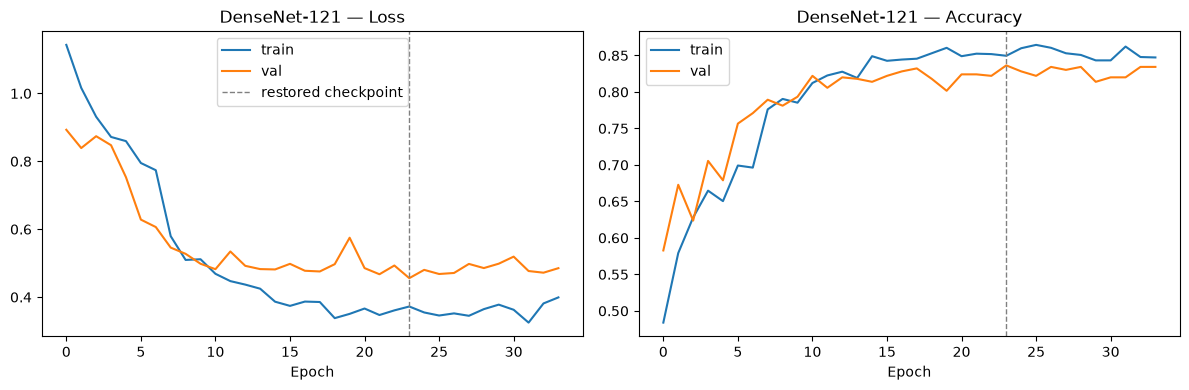

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.783


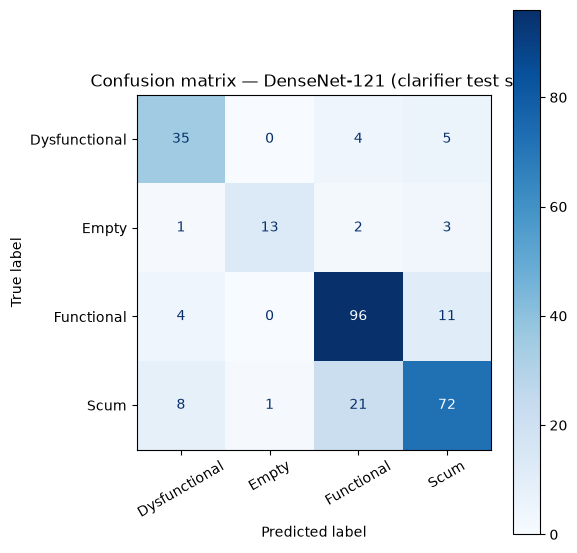

               precision    recall  f1-score   support

Dysfunctional      0.729     0.795     0.761        44
        Empty      0.929     0.684     0.788        19
   Functional      0.780     0.865     0.821       111
         Scum      0.791     0.706     0.746       102

     accuracy                          0.783       276
    macro avg      0.807     0.763     0.779       276
 weighted avg      0.786     0.783     0.781       276



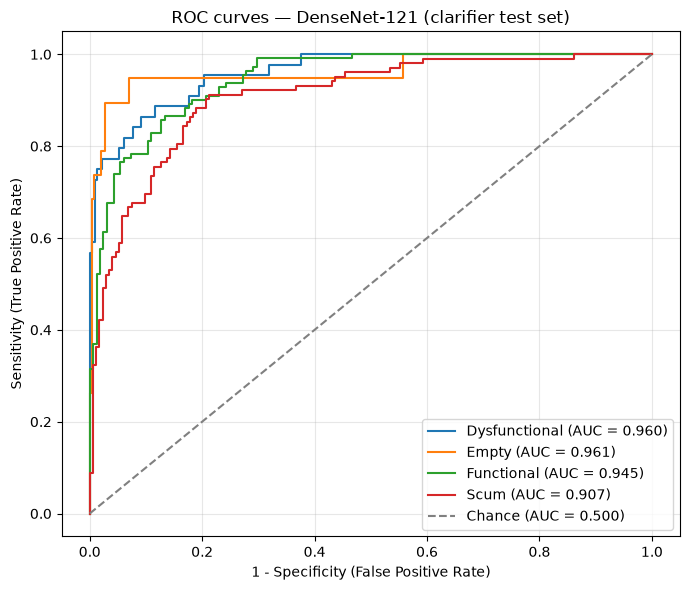

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.960
  Empty          : 0.961
  Functional     : 0.945
  Scum           : 0.907

Mean AUC: 0.943


(np.float64(0.782608695652174),
 {'Dysfunctional': 0.9601293103448276,
  'Empty': 0.9610894941634242,
  'Functional': 0.9452361452361453,
  'Scum': 0.9070317782285328})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_densenet121.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
